# Energy Consumption Prediction

<img src='https://www.energids.be/nl/media/lightboximg/46/image.jpg'>

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
df = pd.read_csv('household_power_consumption.txt', sep=';', encoding='latin-1', low_memory=False)   

In [3]:
#EDA

In [4]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [5]:
df.shape

(2075259, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [7]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [8]:
#Feature Enginerring

In [9]:
df = df.drop('Sub_metering_3', axis=1)

In [10]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000


In [11]:
# Sayısal kolonları float'a çevirelim
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [12]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
dtype: int64

In [13]:
# Eksik değerleri kaldır
df.dropna(subset=['Global_active_power','Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2'], inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
dtypes: float64(6), object(2)
memory usage: 140.7+ MB


In [15]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0


In [16]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

df = df.drop(['Date', 'Time'], axis=1)

# DateTime'e göre sırala
df = df.sort_values('Datetime').reset_index(drop=True)

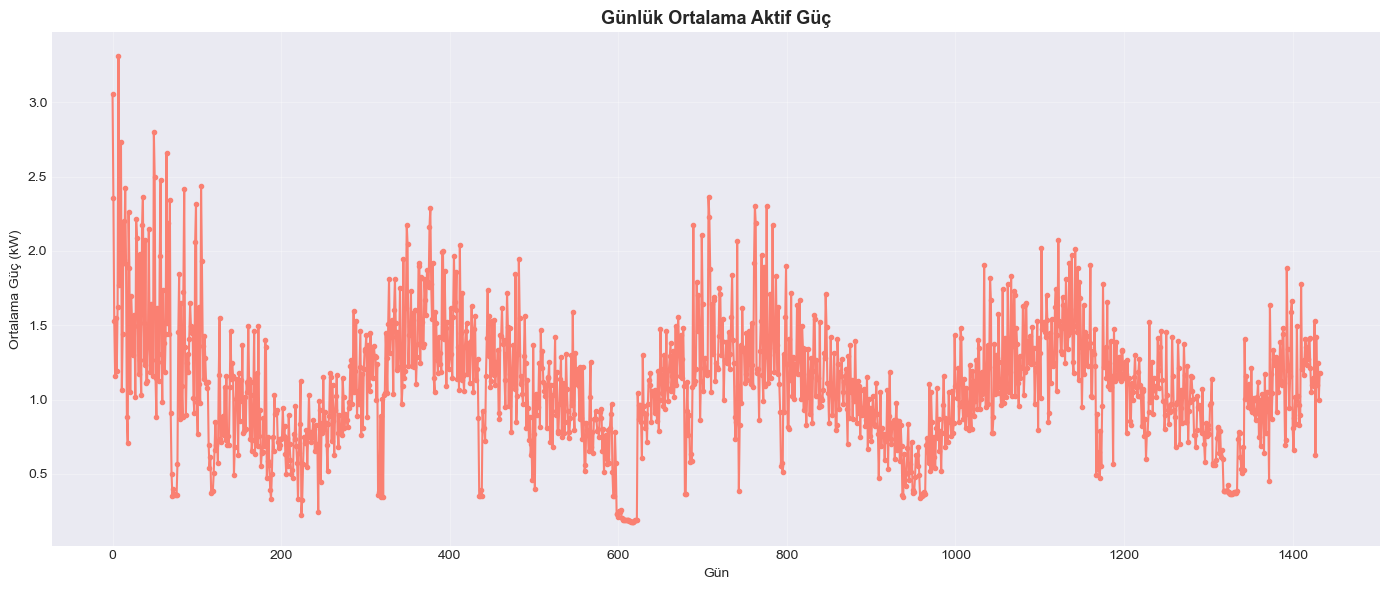

In [17]:
# Günlük ortalama
df['Day'] = df['Datetime'].dt.date
daily_avg = df.groupby('Day')['Global_active_power'].mean()

plt.figure(figsize=(14, 6))
plt.plot(range(len(daily_avg)), daily_avg.values, linewidth=1.5, marker='o', markersize=3, color='#FA8072')
plt.title('Günlük Ortalama Aktif Güç', fontsize=13, fontweight='bold')
plt.xlabel('Gün')
plt.ylabel('Ortalama Güç (kW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

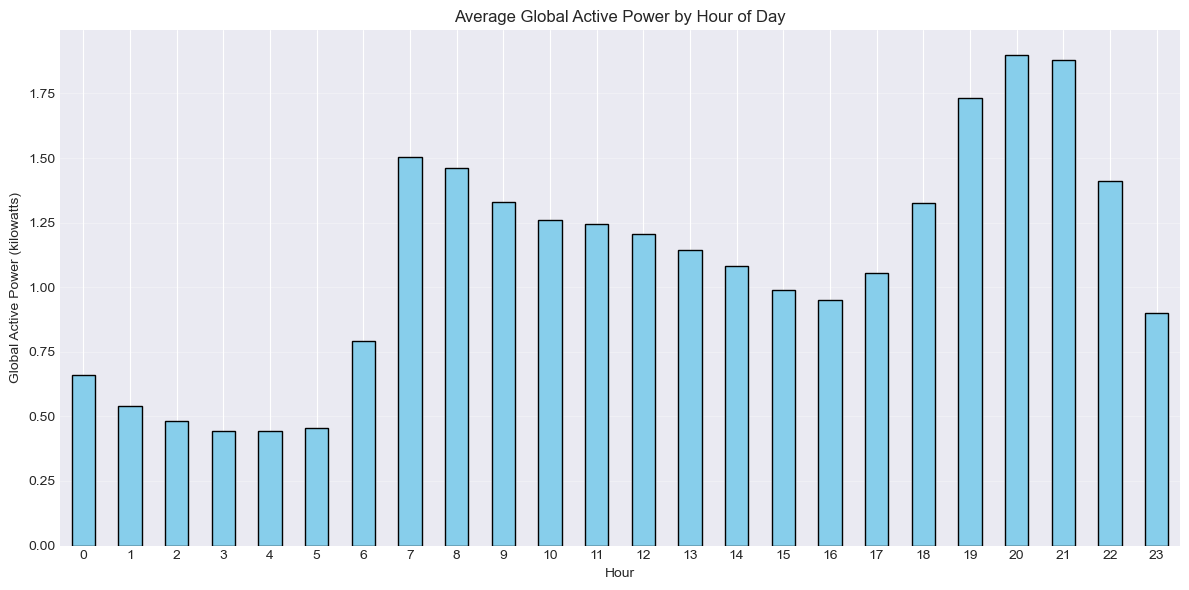

In [18]:
# Saatlik ortalama
df['Hour'] = df['Datetime'].dt.hour
hourly_avg = df.groupby('Hour')['Global_active_power'].mean()

# Plot
plt.figure(figsize=(12, 6))
hourly_avg.plot(kind='bar', color='#87CEEB', edgecolor='black')
plt.title('Average Global Active Power by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Global Active Power (kilowatts)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

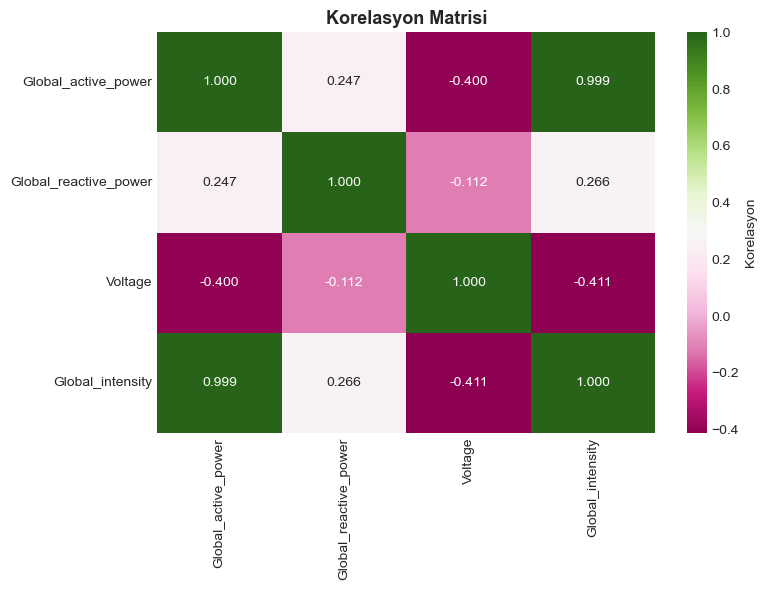

In [19]:
#Korelasyon Matrix
correlation_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']
corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='PiYG', cbar_kws={'label': 'Korelasyon'})
plt.title('Korelasyon Matrisi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Datetime,Day,Hour
0,4.216,0.418,234.84,18.4,0.0,1.0,2006-12-16 17:24:00,2006-12-16,17
1,5.360,0.436,233.63,23.0,0.0,1.0,2006-12-16 17:25:00,2006-12-16,17
2,5.374,0.498,233.29,23.0,0.0,2.0,2006-12-16 17:26:00,2006-12-16,17
3,5.388,0.502,233.74,23.0,0.0,1.0,2006-12-16 17:27:00,2006-12-16,17
4,3.666,0.528,235.68,15.8,0.0,1.0,2006-12-16 17:28:00,2006-12-16,17


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2049280 entries, 0 to 2049279
Data columns (total 9 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Global_intensity       float64       
 4   Sub_metering_1         float64       
 5   Sub_metering_2         float64       
 6   Datetime               datetime64[ns]
 7   Day                    object        
 8   Hour                   int32         
dtypes: datetime64[ns](1), float64(6), int32(1), object(1)
memory usage: 132.9+ MB


In [22]:
# Sayısal Veri
df = df[numeric_cols].values

# Ölçeklendirme
scaler = MinMaxScaler()
df = scaler.fit_transform(df)

In [23]:
# Sequence Oluşturma
def create_sequences(data, lookback=24):
    x, y = [], []
    for i in range(lookback, len(data)):
        x.append(data[i-lookback:i])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

lookback = 60  # 1 saatlik veri
x, y = create_sequences(df, lookback)

In [24]:
# Train-Test Split
train_size = int(len(x) * 0.8)
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [25]:
# LSTM Model
model = Sequential([
    LSTM(50, activation='relu', return_sequences=True, 
         input_shape=(lookback, x_train.shape[2])),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

In [26]:
# Eğitim
history = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/5
40985/40985 ━━━━━━━━━━━━━━━━━━━━ 2283s 55ms/step - loss: 7.8955e-04 - mae: 0.0148 - val_loss: 5.0562e-04 - val_mae: 0.0132
Epoch 2/5
40985/40985 ━━━━━━━━━━━━━━━━━━━━ 2263s 55ms/step - loss: 7.3893 - mae: 0.0157 - val_loss: 5.6166e-04 - val_mae: 0.0158
Epoch 3/5
40985/40985 ━━━━━━━━━━━━━━━━━━━━ 2868s 70ms/step - loss: 6.8017e-04 - mae: 0.0130 - val_loss: 5.3681e-04 - val_mae: 0.0151
Epoch 4/5
40985/40985 ━━━━━━━━━━━━━━━━━━━━ 2304s 56ms/step - loss: 6.3426e-04 - mae: 0.0127 - val_loss: 6.6067e-04 - val_mae: 0.0174
Epoch 5/5
40985/40985 ━━━━━━━━━━━━━━━━━━━━ 2707s 66ms/step - loss: 6.1933e-04 - mae: 0.0125 - val_loss: 6.5800e-04 - val_mae: 0.0179


In [27]:
# tahmin
tahmin = model.predict(x_test)

12808/12808 ━━━━━━━━━━━━━━━━━━━━ 323s 25ms/step


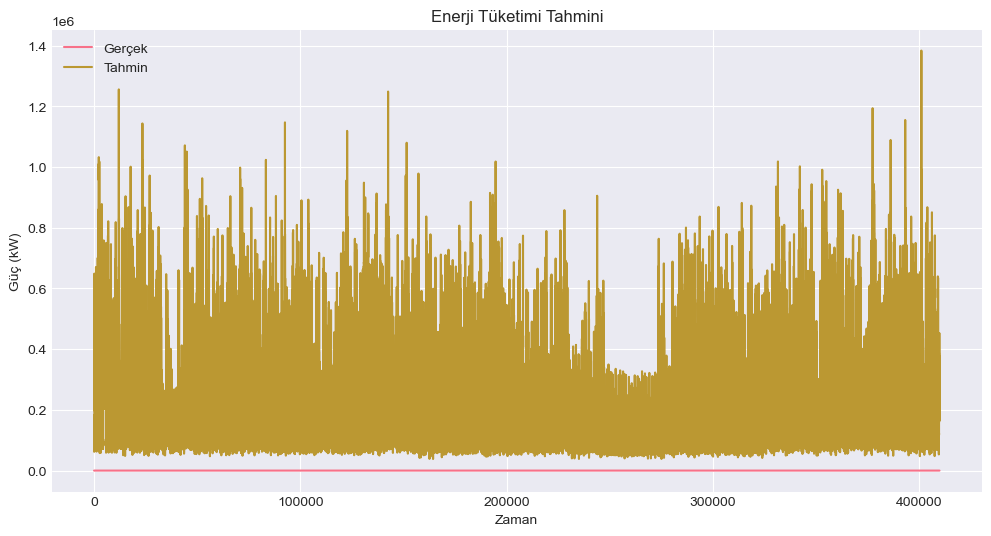

In [38]:
# Visualization
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Gerçek')
plt.plot(tahmin, label='Tahmin')
plt.legend()
plt.title('Enerji Tüketimi Tahmini')
plt.xlabel('Zaman')
plt.ylabel('Güç (kW)')
plt.show()

12808/12808 ━━━━━━━━━━━━━━━━━━━━ 433s 34ms/step
RMSE: 0.2585, MAE: 0.1810


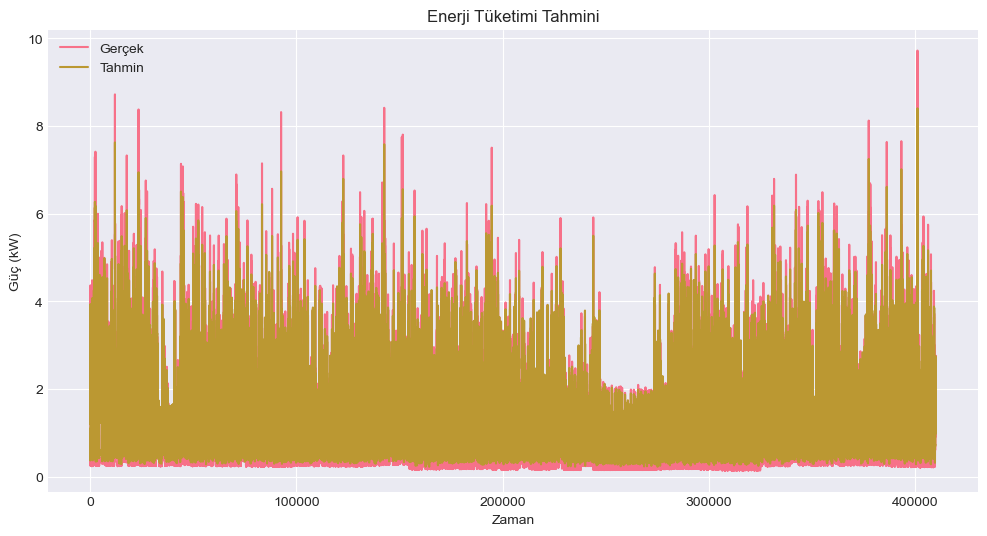

In [39]:
# 1. First, make predictions with your model
y_pred_scaled = model.predict(x_test)

# 2. Inverse Scaling for predictions
# Create array with same shape as original scaled data
y_pred_full = np.zeros((y_pred_scaled.shape[0], x_test.shape[2]))
y_pred_full[:, 0] = y_pred_scaled.flatten()
y_pred = scaler.inverse_transform(y_pred_full)[:, 0]

# 3. Inverse Scaling for actual values
y_test_full = np.zeros((len(y_test), x_test.shape[2]))
y_test_full[:, 0] = y_test
y_test_inverse = scaler.inverse_transform(y_test_full)[:, 0]

# 4. Metrics
rmse = np.sqrt(mean_squared_error(y_test_inverse, y_pred))
mae = mean_absolute_error(y_test_inverse, y_pred)
print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}")

# 5. Visualization
plt.figure(figsize=(12, 6))
plt.plot(y_test_inverse, label='Gerçek')
plt.plot(y_pred, label='Tahmin')
plt.legend()
plt.title('Enerji Tüketimi Tahmini')
plt.xlabel('Zaman')
plt.ylabel('Güç (kW)')
plt.show()